<a href="https://colab.research.google.com/github/Janeyy-A/PINN_KAN-PIKAN/blob/main/PINN_KANV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KAN & PINN — 2D Advection-Diffusion PDE (Second Spatial Dimension)

## PDE
$$\frac{\partial u}{\partial t} + c_x \frac{\partial u}{\partial x} + c_y \frac{\partial u}{\partial y} = D\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

**Domain:** $x, y \in [0, L]$, $t \in [0, T]$  
**IC:** $u(x, y, 0) = \sin\!\left(\dfrac{2\pi}{L^2}\, x y\right)$  
**BC:** Dirichlet, constant $= 0$ on all boundaries  
**Focus:** Second spatial dimension ($y$-direction)

---

### Fairness Notes
- Both models operate on the **same domain, PDE parameters, IC, and BC**.
- Both are evaluated against the **same ADI–Crank–Nicolson ground truth**.
- Each model uses the **best version of its own training setup** — their methodologies remain distinct by design.
- **BC = 0** is chosen because `sin(2π/L²·xy)` evaluates to exactly 0 on the boundaries `x=0` and `y=0`, minimising the IC/BC discontinuity.
- **PINN inputs are normalised** to `[-1, 1]` (same as KAN) to ensure neither model is disadvantaged by poor gradient scaling.
- **Both models use a learning-rate scheduler** (`ReduceLROnPlateau`) for fair convergence opportunity.
- **PINN loss weights** `(w_f=1, w_ic=5, w_bc=1)` — IC is up-weighted to anchor the solution from t=0.
- **KAN convergence threshold** kept at `1e-6` (tightened from `1e-5`) so the model is not stopped prematurely.
- **PINN convergence threshold** set to `1e-6` with patience 2000 to allow full training before stopping.
- **PINN adds an L-BFGS phase** after Adam to reduce the PDE residual using second-order information.
- **PINN resamples collocation points** every 1000 epochs to avoid overfitting to fixed locations.

In [ ]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.2 MB/s eta 0:00:000:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 75.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 94.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 5.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 3.1 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.4 MB/s eta 0:00:0000:0100:01
     ━━━━━

## 0. Imports & Shared Setup

In [ ]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

OUT_DIR = '/content/combined_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

def save_and_show(filename):
    fpath = os.path.join(OUT_DIR, filename)
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  -> saved {filename}')

Device: cuda


## 1. Shared PDE Parameters

In [ ]:
# ── Shared PDE / domain parameters ────────────────────────────────────────────
L      = 2.0    # domain length
CX     = 1.0    # advection speed x
CY     = 1.0    # advection speed y  <-- SECOND SPATIAL DIMENSION
D      = 0.5    # diffusion coefficient
T      = 1.0    # total simulation time
BC_VAL = 0.0    # Dirichlet BC = 0 on all boundaries
                # Chosen because sin(2pi/L^2 * x*y) = 0 exactly on x=0 and y=0,
                # minimising the IC/BC discontinuity relative to BC=1.

# Shared spatial/temporal grid
Nx = 80
Ny = 80
DX = L / Nx    # 0.025
DY = L / Ny    # 0.025
DT = 2e-3
Nt = int(T / DT)

x_grid = np.linspace(0.0, L, Nx + 1)
y_grid = np.linspace(0.0, L, Ny + 1)

# Shared IC (used by both GT solver, KAN dataset, and PINN sampler)
def ic_xy(x, y):
    """IC: u(x,y,0) = sin(2*pi/L^2 * x*y)"""
    return np.sin(2.0 * np.pi / L**2 * x * y)

# Shared input normalisation to [-1, 1]  (applied to BOTH KAN and PINN)
# Bounds: x in [0,L], y in [0,L], t in [0,T]
def normalise_inputs(x, y, t):
    """Normalise (x, y, t) -> [-1, 1] using known domain bounds."""
    xn = 2.0 * x / L - 1.0
    yn = 2.0 * y / L - 1.0
    tn = 2.0 * t / T - 1.0
    return xn, yn, tn

print('=' * 65)
print('  Shared PDE Parameters')
print('=' * 65)
print(f'  Domain  : x,y in [0, {L}],  t in [0, {T}]')
print(f'  Grid    : Nx={Nx}, Ny={Ny}, Nt={Nt}')
print(f'  Dx={DX:.4f}  Dy={DY:.4f}  Dt={DT}')
print(f'  cx={CX},  cy={CY},  D={D}')
print(f'  IC: u(x,y,0) = sin(2*pi/L^2 * x*y)')
print(f'  BC: u = {BC_VAL} on all boundaries (Dirichlet)')
print(f'  Input normalisation: x,y,t -> [-1, 1]  (both models)')
print('=' * 65)

  Shared PDE Parameters
  Domain  : x,y in [0, 2.0],  t in [0, 1.0]
  Grid    : Nx=80, Ny=80, Nt=500
  Dx=0.0250  Dy=0.0250  Dt=0.002
  cx=1.0,  cy=1.0,  D=0.5
  IC: u(x,y,0) = sin(2*pi/L^2 * x*y)
  BC: u = 0.0 on all boundaries (Dirichlet)
  Input normalisation: x,y,t -> [-1, 1]  (both models)


## 2. Ground Truth — ADI Crank–Nicolson Solver

In [ ]:
def thomas(a, b, c, d):
    """Thomas algorithm (tridiagonal solver)."""
    n = len(b)
    cp = np.zeros(n - 1)
    dp = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n - 1):
        denom = b[i] - a[i - 1] * cp[i - 1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i - 1] * dp[i - 1]) / denom
    denom = b[-1] - a[-1] * cp[-1]
    dp[-1] = (d[-1] - a[-1] * dp[-2]) / denom
    sol = np.zeros(n)
    sol[-1] = dp[-1]
    for i in reversed(range(n - 1)):
        sol[i] = dp[i] - cp[i] * sol[i + 1]
    return sol


def solve_2d_adi():
    """
    ADI-Crank-Nicolson solver with upwind advection.
    Dirichlet BC = BC_VAL on all boundaries.
    IC = sin(2*pi/L^2 * x*y), overridden to BC_VAL at boundary nodes.
    """
    x = x_grid
    y = y_grid
    t = np.linspace(0, T, Nt + 1)

    C = np.zeros((Nt + 1, Ny + 1, Nx + 1))
    X, Y = np.meshgrid(x, y, indexing='xy')
    C[0] = ic_xy(X, Y)
    # Enforce Dirichlet BC on IC at boundary nodes
    C[0, 0, :] = C[0, -1, :] = C[0, :, 0] = C[0, :, -1] = BC_VAL

    rx = D * DT / (2 * DX * DX)
    ry = D * DT / (2 * DY * DY)

    ax_d = -rx * np.ones(Nx - 2)
    bx_d = (1 + 2 * rx) * np.ones(Nx - 1)
    cx_d = -rx * np.ones(Nx - 2)

    ay_d = -ry * np.ones(Ny - 2)
    by_d = (1 + 2 * ry) * np.ones(Ny - 1)
    cy_d = -ry * np.ones(Ny - 2)

    for n in range(Nt):
        U = C[n].copy()

        A = np.zeros_like(U)
        A[:, 1:-1] += CX * (U[:, 1:-1] - U[:, :-2]) / DX   # upwind x
        A[1:-1, :] += CY * (U[1:-1, :] - U[:-2, :]) / DY   # upwind y

        Lap = np.zeros_like(U)
        Lap[1:-1, 1:-1] = (
            (U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]) / (DX * DX)
            + (U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]) / (DY * DY)
        )

        RHS = U - DT * A + (D * DT / 2) * Lap

        # x-sweep
        Ustar = U.copy()
        for j in range(1, Ny):
            Ustar[j, 1:-1] = thomas(ax_d, bx_d, cx_d, RHS[j, 1:-1])
        Ustar[0, :] = Ustar[-1, :] = Ustar[:, 0] = Ustar[:, -1] = BC_VAL

        # y-sweep
        Un = Ustar.copy()
        for i in range(1, Nx):
            Un[1:-1, i] = thomas(ay_d, by_d, cy_d, Ustar[1:-1, i])
        Un[0, :] = Un[-1, :] = Un[:, 0] = Un[:, -1] = BC_VAL

        C[n + 1] = Un

    return x, y, t, C


print('Solving ground truth (ADI-Crank-Nicolson) ...', flush=True)
t0_gt = time.time()
x_sol, y_sol, t_sol, C_gt = solve_2d_adi()
print(f'  Done in {time.time() - t0_gt:.2f}s  |  shape: {C_gt.shape}')
# C_gt shape: (Nt+1, Ny+1, Nx+1)

Solving ground truth (ADI-Crank-Nicolson) ...
  Done in 10.30s  |  shape: (501, 81, 81)


## 3. KAN Model Definition

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Vectorized KAN (fully batched B-spline activations)
# ══════════════════════════════════════════════════════════════════════════════

class VKANLayer(nn.Module):
    """
    Vectorized KAN layer: R^{in_dim} -> R^{out_dim}.
    All B-spline evaluations are batched via einsum — no Python loops at runtime.
    """
    def __init__(self, in_dim, out_dim, grid_size=5, spline_order=3,
                 grid_lo=-1.0, grid_hi=1.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.k       = spline_order
        n_basis      = grid_size + spline_order

        self.coeff = nn.Parameter(torch.zeros(in_dim, out_dim, n_basis))
        nn.init.normal_(self.coeff, std=0.1)

        self.res_w = nn.Parameter(torch.zeros(in_dim, out_dim))

        h     = (grid_hi - grid_lo) / grid_size
        knots = torch.linspace(
            grid_lo - spline_order * h,
            grid_hi + spline_order * h,
            grid_size + 2 * spline_order + 1
        )
        self.register_buffer('knots', knots)

    def _basis(self, x):
        k  = self.k
        t  = self.knots
        n  = len(t) - k - 1
        xv = x.unsqueeze(-1)
        tv = t.view(1, 1, -1)
        B  = ((xv >= tv[:, :, :-1]) & (xv < tv[:, :, 1:])).float()
        for r in range(1, k + 1):
            tL  = tv[:, :, :-(r + 1)];  tR  = tv[:, :, r:-1]
            dL  = (tR  - tL ).clamp(min=1e-8)
            tL2 = tv[:, :, 1:-r];       tR2 = tv[:, :, r + 1:]
            dR  = (tR2 - tL2).clamp(min=1e-8)
            B   = ((xv - tL) / dL) * B[:, :, :-1] + \
                  ((tR2 - xv) / dR) * B[:, :, 1:]
        return B[:, :, :n]

    def forward(self, x):
        B      = self._basis(x)
        spline = torch.einsum('bin,ion->bio', B, self.coeff)
        res    = torch.einsum('bi,io->bio', F.silu(x), self.res_w)
        return (spline + 0.1 * res).sum(dim=1)


class KAN(nn.Module):
    """Stack of VKANLayer with LayerNorm between hidden layers."""
    def __init__(self, widths, grid_size=5, spline_order=3):
        super().__init__()
        layers, norms = [], []
        for i in range(len(widths) - 1):
            layers.append(VKANLayer(widths[i], widths[i+1], grid_size, spline_order))
            if i < len(widths) - 2:
                norms.append(nn.LayerNorm(widths[i+1]))
        self.layers = nn.ModuleList(layers)
        self.norms  = nn.ModuleList(norms)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.norms):
                x = self.norms[i](x)
        return x

print('KAN model class defined.')

KAN model class defined.


## 4. KAN — Dataset & Training

In [ ]:
# ── Build KAN dataset from ground truth snapshots ─────────────────────────────
# Increased N_SNAPS from 40 -> 100 for denser temporal coverage of the solution
N_SNAPS    = 100
save_every = max(1, Nt // N_SNAPS)
snap_idx_list = list(range(0, Nt + 1, save_every))
if snap_idx_list[-1] != Nt:
    snap_idx_list.append(Nt)

snap_t = t_sol[snap_idx_list]
snap_U = C_gt[snap_idx_list]   # (n_snaps, Ny+1, Nx+1)

# Build (x, y, t) -> u dataset
# C_gt indexing is (t, y, x); transpose to (x, y) for consistent ordering
XX, YY = np.meshgrid(x_grid, y_grid, indexing='ij')  # (Nx+1, Ny+1)
snap_U_ij = snap_U.transpose(0, 2, 1)  # (n_snaps, Nx+1, Ny+1)

inp_list, tgt_list = [], []
for k, tk in enumerate(snap_t):
    t_plane = np.full((Nx + 1, Ny + 1), tk, dtype=np.float32)
    inp_list.append(
        np.stack([XX, YY, t_plane], axis=-1).astype(np.float32).reshape(-1, 3)
    )
    tgt_list.append(snap_U_ij[k].astype(np.float32).ravel())

inputs_kan  = np.concatenate(inp_list, axis=0)   # (N, 3) columns: [x, y, t]
targets_kan = np.concatenate(tgt_list, axis=0)   # (N,)

# Normalise inputs to [-1, 1] using the shared normalisation function
xn_kan, yn_kan, tn_kan = normalise_inputs(
    inputs_kan[:, 0], inputs_kan[:, 1], inputs_kan[:, 2]
)
inputs_kan_n = np.stack([xn_kan, yn_kan, tn_kan], axis=1).astype(np.float32)

N_kan = len(inputs_kan_n)
rng   = np.random.default_rng(42)
idx   = rng.permutation(N_kan)
split = int(0.85 * N_kan)
tr, va = idx[:split], idx[split:]

X_tr = torch.from_numpy(inputs_kan_n[tr])
y_tr = torch.from_numpy(targets_kan[tr]).unsqueeze(1)
X_va = torch.from_numpy(inputs_kan_n[va])
y_va = torch.from_numpy(targets_kan[va]).unsqueeze(1)

BATCH        = 512
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH * 8)

print(f'KAN Dataset: {N_kan:,} samples  |  train {len(tr):,} / val {len(va):,}')
print(f'Snapshots  : {len(snap_t)}')


KAN Dataset: 662,661 samples  |  train 563,261 / val 99,400
Snapshots  : 101


In [ ]:
# ── KAN model & optimiser ─────────────────────────────────────────────────────
# Architecture widened: [3,12,12,1] -> [3,32,32,32,1]  (more expressive capacity)
# Grid size increased  : 5 -> 8  (primary KAN expressiveness lever)
# Threshold tightened  : 1e-5 -> 1e-6  (don't stop training too early)
# Patience increased   : 25 -> 50  (give more room before declaring convergence)
# Max epochs increased : 3000 -> 5000  (larger net needs more time)
KAN_WIDTHS     = [3, 32, 32, 32, 1]
KAN_GRID_SIZE  = 8
KAN_SPLINE_ORD = 3

kan_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_n_params = sum(p.numel() for p in kan_model.parameters())
print(f'KAN architecture : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_n_params:,}')

kan_optimizer = torch.optim.AdamW(kan_model.parameters(), lr=3e-3, weight_decay=1e-4)
kan_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    kan_optimizer, mode='min', patience=15, factor=0.5, min_lr=5e-6
)
kan_criterion = nn.MSELoss()

# ── KAN training loop ─────────────────────────────────────────────────────────
KAN_MAX_WALL   = 7200.0
KAN_THRESHOLD  = 1e-6   # tightened from 1e-5 -> 1e-6
KAN_PATIENCE   = 50     # increased from 25 -> 50
KAN_MAX_EPOCHS = 5000   # increased from 3000 -> 5000

kan_train_losses, kan_val_losses, kan_lr_history = [], [], []
kan_best_val, kan_best_state = float('inf'), None
kan_no_improve  = 0
kan_stop_reason = 'max_epochs'
kan_prev_val    = float('inf')
kan_wall_start  = time.time()

print(f'\n{"Epoch":>6} | {"Train Loss":>12} | {"Val MSE":>12} | {"LR":>9} | {"Wall":>7}')
print('-' * 60)

for epoch in range(1, KAN_MAX_EPOCHS + 1):
    elapsed = time.time() - kan_wall_start
    if elapsed >= KAN_MAX_WALL:
        kan_stop_reason = 'time_limit'; break

    kan_model.train()
    t_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        kan_optimizer.zero_grad()
        loss = kan_criterion(kan_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(kan_model.parameters(), 1.0)
        kan_optimizer.step()
        t_loss += loss.item() * xb.size(0)
    t_loss /= len(X_tr)

    kan_model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            v_loss += kan_criterion(kan_model(xb), yb).item() * xb.size(0)
    v_loss /= len(X_va)

    kan_scheduler.step(v_loss)
    cur_lr = kan_optimizer.param_groups[0]['lr']

    kan_train_losses.append(t_loss)
    kan_val_losses.append(v_loss)
    kan_lr_history.append(cur_lr)

    if v_loss < kan_best_val:
        kan_best_val   = v_loss
        kan_best_state = {k: v.cpu().clone() for k, v in kan_model.state_dict().items()}

    delta = abs(kan_prev_val - v_loss)
    if epoch % 50 == 0 or epoch == 1:
        print(f'{epoch:>6} | {t_loss:>12.6f} | {v_loss:>12.6f} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

    if epoch > 50:
        kan_no_improve = kan_no_improve + 1 if delta < KAN_THRESHOLD else 0
        if kan_no_improve >= KAN_PATIENCE:
            kan_stop_reason = 'convergence'
            print(f'\n  KAN converged at epoch {epoch}! |DLoss|={delta:.2e} < {KAN_THRESHOLD:.0e}')
            break

    kan_prev_val = v_loss

if kan_best_state:
    kan_model.load_state_dict(kan_best_state)
    kan_model.to(device)

kan_total_time  = time.time() - kan_wall_start
kan_final_epoch = len(kan_train_losses)

print('\n' + '=' * 60)
print(f'  KAN Stop reason   : {kan_stop_reason}')
print(f'  KAN Epochs run    : {kan_final_epoch}')
print(f'  KAN Best val MSE  : {kan_best_val:.6f}')
print(f'  KAN Training time : {kan_total_time:.1f}s ({kan_total_time/60:.1f} min)')
print('=' * 60)


KAN architecture : [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304

 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.007475 |     0.000535 |  3.00e-03 |   0.0s
    50 |     0.000005 |     0.000024 |  3.00e-03 | 725.4s
   100 |     0.000000 |     0.000001 |  7.50e-04 | 1459.5s
   150 |     0.000000 |     0.000000 |  1.88e-04 | 2193.0s

  KAN converged at epoch 195! |DLoss|=2.02e-08 < 1e-06

  KAN Stop reason   : convergence
  KAN Epochs run    : 195
  KAN Best val MSE  : 0.000000
  KAN Training time : 2863.3s (47.7 min)


## 5. KAN — Predictions & Metrics

In [ ]:
# ── Full KAN predictions over all snapshot points ─────────────────────────────
kan_model.eval()
CHUNK = 4096
kan_pred_list = []
X_all_t = torch.from_numpy(inputs_kan_n).to(device)

with torch.no_grad():
    for i in range(0, len(X_all_t), CHUNK):
        kan_pred_list.append(kan_model(X_all_t[i:i+CHUNK]).cpu().numpy().ravel())

kan_pred_all = np.concatenate(kan_pred_list)
kan_true_all = targets_kan

kan_mse_full = float(np.mean((kan_pred_all - kan_true_all)**2))
kan_rmse_all = float(np.sqrt(kan_mse_full))
kan_rel_err  = float(
    np.mean(np.abs(kan_pred_all - kan_true_all)) / (np.mean(np.abs(kan_true_all)) + 1e-12)
)

print(f'KAN Full-dataset MSE  : {kan_mse_full:.6f}')
print(f'KAN RMSE              : {kan_rmse_all:.6f}')
print(f'KAN Relative L1 error : {kan_rel_err*100:.2f} %')

# Reshape predictions to (n_snaps, Nx+1, Ny+1)
KAN_pred_snaps = kan_pred_all.reshape(len(snap_t), Nx + 1, Ny + 1)
KAN_true_snaps = kan_true_all.reshape(len(snap_t), Nx + 1, Ny + 1)

KAN Full-dataset MSE  : 0.000000
KAN RMSE              : 0.000124
KAN Relative L1 error : 0.06 %


## 6. KAN — Plots

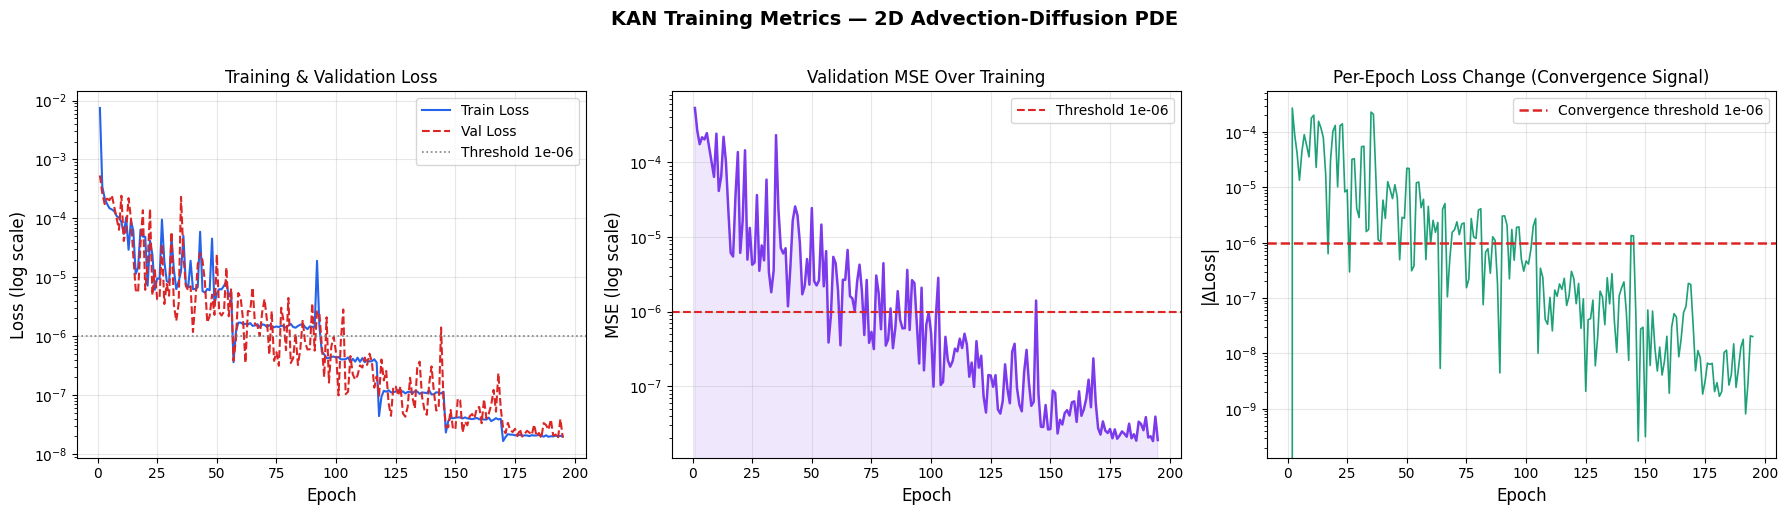

  -> saved KAN_01_training_metrics.png


In [ ]:
# ── KAN Plot 1: Training Metrics ──────────────────────────────────────────────
FS = 12
ep_a_kan    = np.arange(1, kan_final_epoch + 1)
snap_idxs_4 = np.linspace(0, len(snap_t) - 1, 4, dtype=int)
ix_mid      = (Nx + 1) // 2   # x ≈ L/2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('KAN Training Metrics — 2D Advection-Diffusion PDE', fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
ax.semilogy(ep_a_kan, kan_train_losses, lw=1.5, color='#2563EB', label='Train Loss')
ax.semilogy(ep_a_kan, kan_val_losses,   lw=1.5, color='#DC2626', ls='--', label='Val Loss')
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.2, label=f'Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS); ax.set_ylabel('Loss (log scale)', fontsize=FS)
ax.set_title('Training & Validation Loss'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(ep_a_kan, kan_val_losses, lw=1.8, color='#7C3AED')
ax.fill_between(ep_a_kan, kan_val_losses, alpha=0.12, color='#7C3AED')
ax.axhline(KAN_THRESHOLD, color='#DC2626', ls='--', lw=1.5, label=f'Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS); ax.set_ylabel('MSE (log scale)', fontsize=FS)
ax.set_title('Validation MSE Over Training'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[2]
delta_arr = np.abs(np.diff(kan_val_losses, prepend=kan_val_losses[0]))
ax.semilogy(ep_a_kan, delta_arr, lw=1.2, color='#059669', alpha=0.9)
ax.axhline(KAN_THRESHOLD, color='#DC2626', ls='--', lw=1.8, label=f'Convergence threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS); ax.set_ylabel('|ΔLoss|', fontsize=FS)
ax.set_title('Per-Epoch Loss Change (Convergence Signal)'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('KAN_01_training_metrics.png')

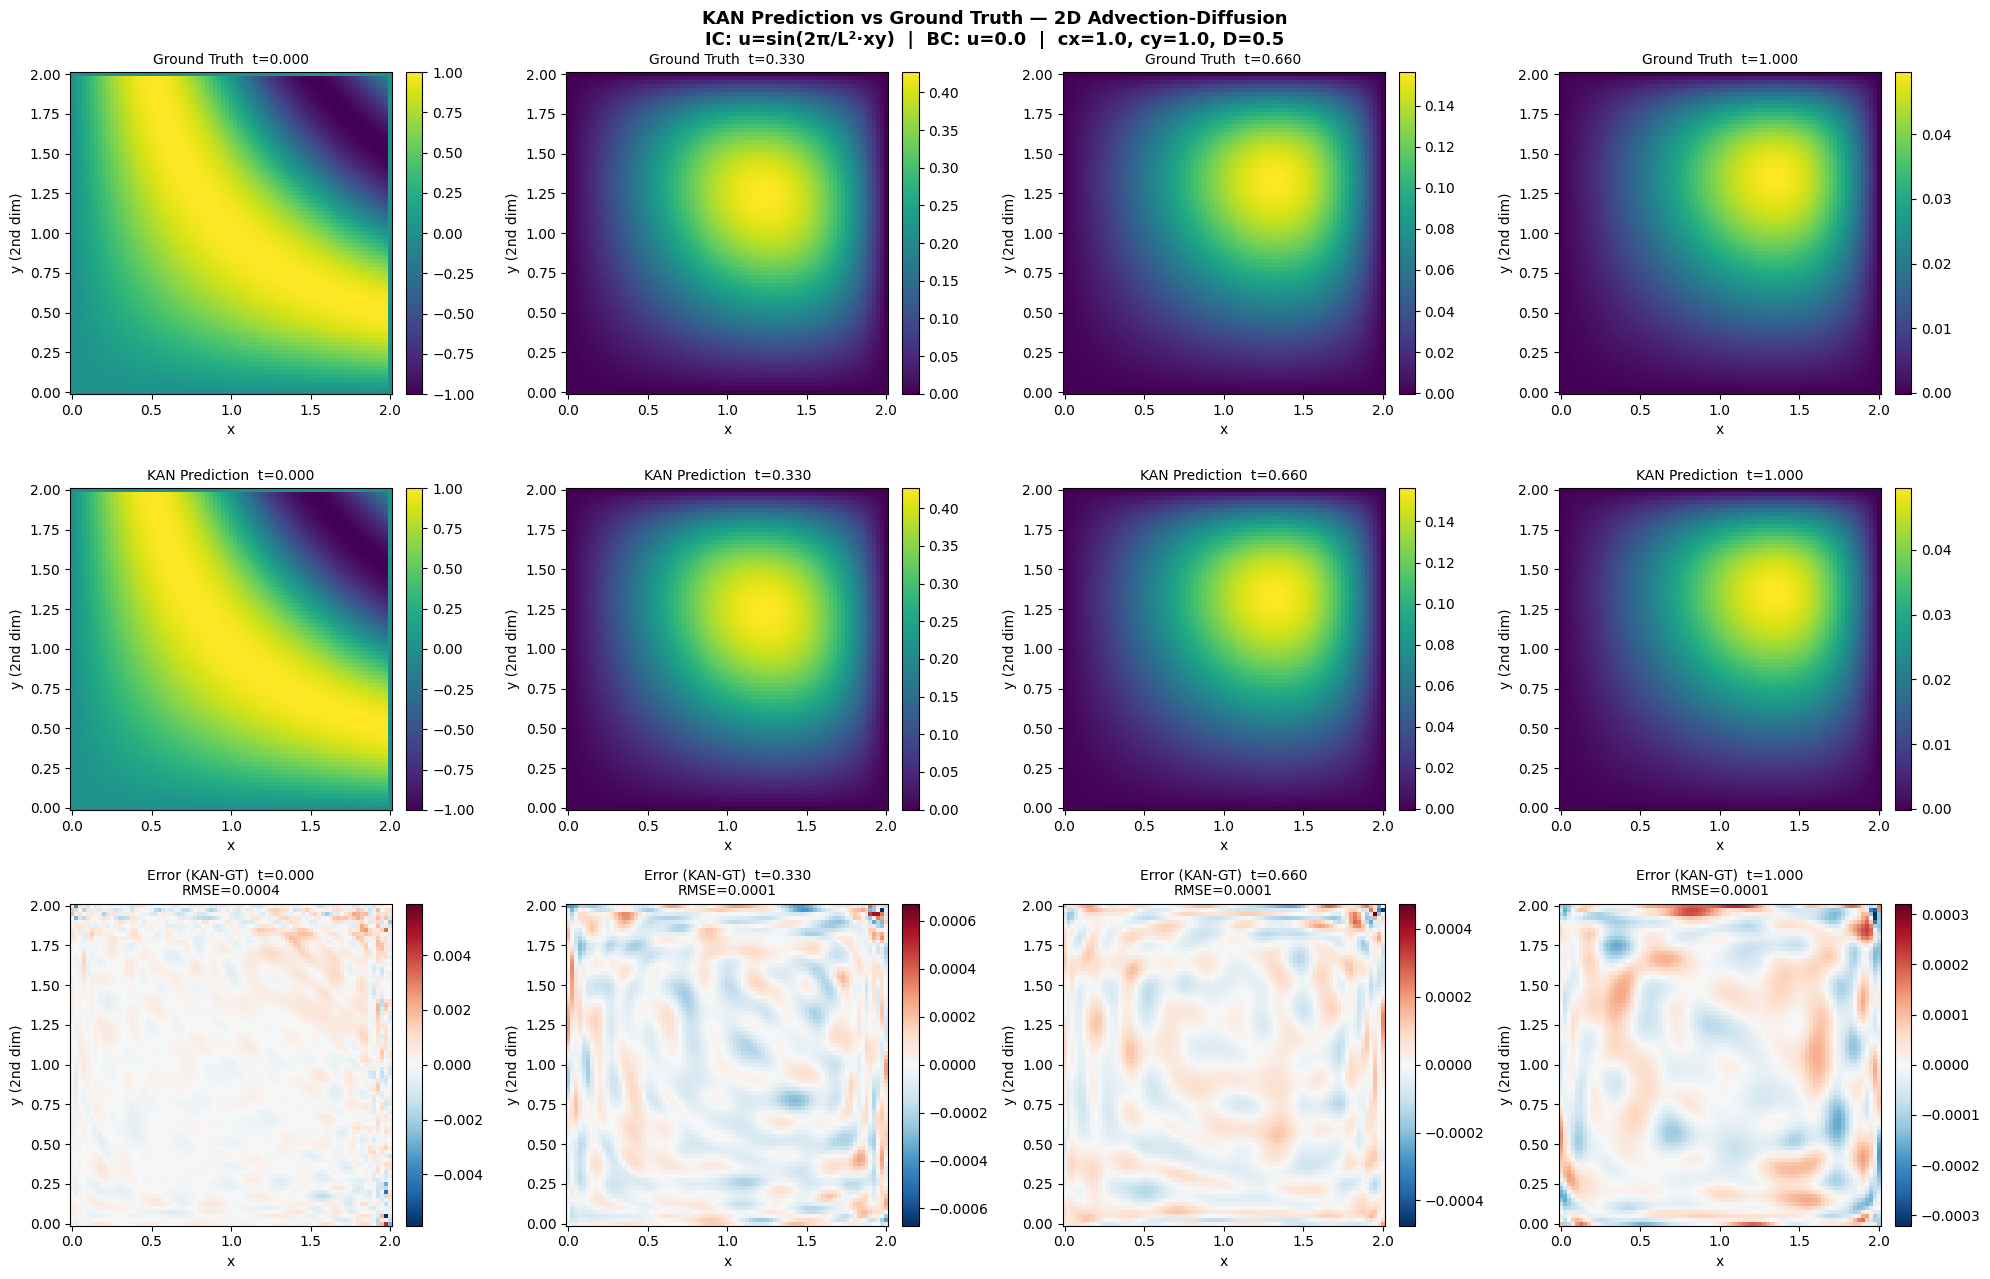

  -> saved KAN_02_snapshot_comparison.png


In [ ]:
# ── KAN Plot 2: Ground Truth vs KAN vs Pointwise Error (4 snapshots) ──────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'KAN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk  = snap_t[si]
    Ugt = KAN_true_snaps[si]
    Ukn = KAN_pred_snaps[si]
    err = Ukn - Ugt
    vmin = min(Ugt.min(), Ukn.min()); vmax = max(Ugt.max(), Ukn.max())
    emax = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'KAN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_k = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (KAN-GT)  t={tk:.3f}\nRMSE={rmse_k:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('KAN_02_snapshot_comparison.png')

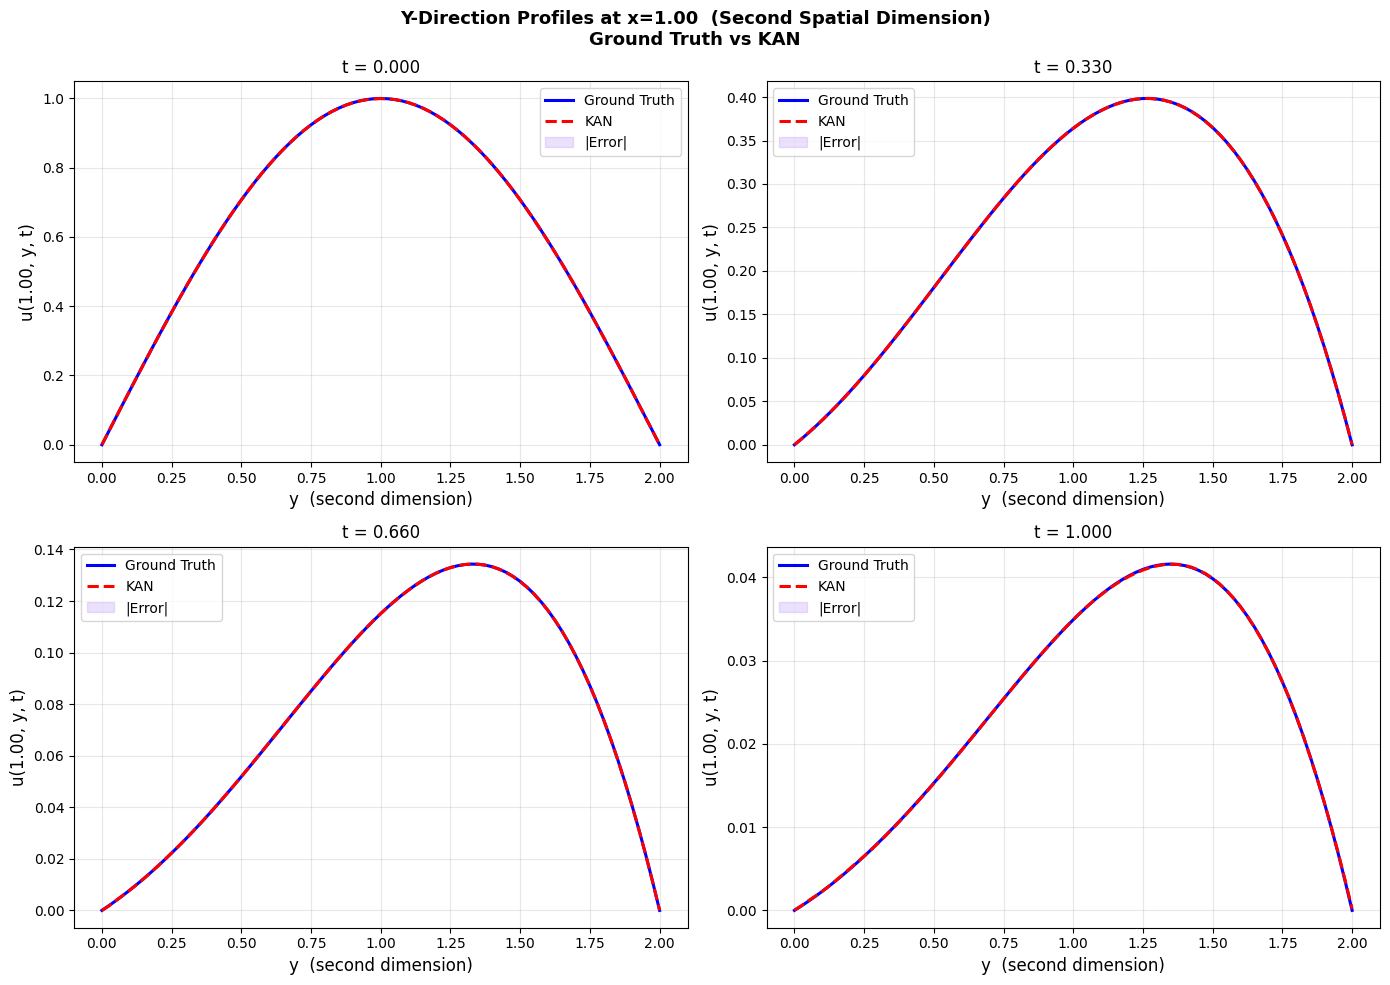

  -> saved KAN_03_y_profiles.png


In [ ]:
# ── KAN Plot 3: Y-Profiles at x ≈ L/2 ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  (Second Spatial Dimension)\n'
    'Ground Truth vs KAN',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    kn_y = KAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'b-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, kn_y, 'r--', lw=2.2, label='KAN')
    ax.fill_between(y_grid, gt_y, kn_y, alpha=0.15, color='#7C3AED', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('KAN_03_y_profiles.png')

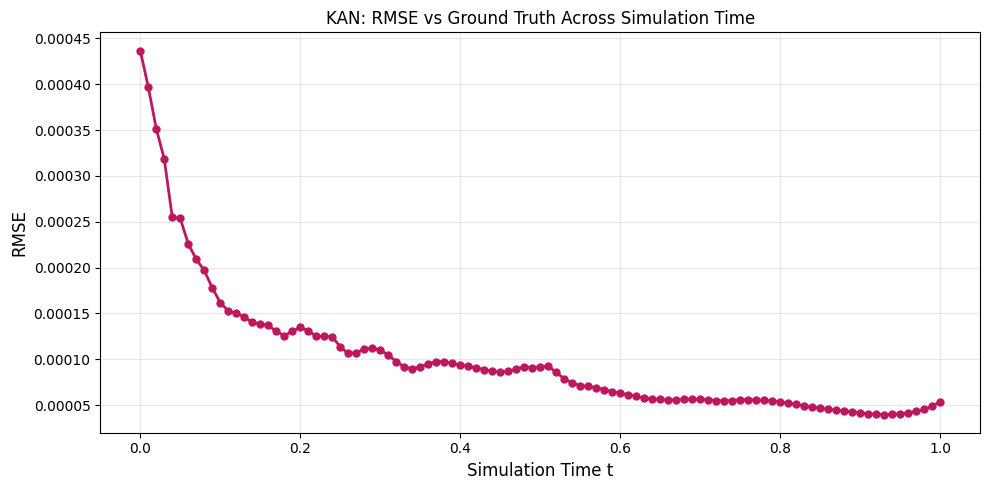

  -> saved KAN_04_rmse_over_time.png


In [ ]:
# ── KAN Plot 4: RMSE Across Simulation Time ───────────────────────────────────
kan_rmse_t = [np.sqrt(np.mean((KAN_pred_snaps[k] - KAN_true_snaps[k])**2)) for k in range(len(snap_t))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, kan_rmse_t, 'o-', color='#BE185D', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('KAN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('KAN_04_rmse_over_time.png')

## 7. PINN Model Definition

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PINN — MLP with Tanh activations
# ══════════════════════════════════════════════════════════════════════════════

class MLP(nn.Module):
    def __init__(self, width=128, depth=6):
        super().__init__()
        layers = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

pinn_model    = MLP().to(device)
pinn_n_params = sum(p.numel() for p in pinn_model.parameters())
print(f'PINN architecture: MLP  width=128  depth=6  params={pinn_n_params:,}')
print(pinn_model)

PINN architecture: MLP  width=128  depth=6  params=83,201
MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 8. PINN — Dataset & Training

In [ ]:
# ── PINN hyperparameters ──────────────────────────────────────────────────────
# N_F increased  : 40000 -> 50000  (denser PDE residual coverage)
# N_IC increased : 10000 -> 20000  (more IC anchoring points)
# Epochs increased: 8000 -> 20000  (Adam phase; L-BFGS phase follows)
# Threshold tightened: 1e-5 -> 1e-6  (same as KAN; don't stop too early)
# Patience increased : 200 -> 2000  (allow training through flat regions)
# Loss weights: w_ic raised 1->5 to anchor IC; PDE and BC stay at 1
# Collocation resampled every 1000 epochs to avoid point-overfit
PINN_N_F            = 50000   # increased from 40000
PINN_N_IC           = 20000   # increased from 10000
PINN_N_BC           = 16000
PINN_EPOCHS_ADAM    = 20000   # increased from 8000
PINN_EPOCHS_LBFGS   = 500     # NEW: L-BFGS fine-tuning phase after Adam
PINN_LR             = 1e-3
PINN_PRINT_EVERY    = 1000    # adjusted for longer run
PINN_EARLY_THRESH   = 1e-6    # tightened from 1e-5 -> 1e-6
PINN_EARLY_PATIENCE = 2000    # increased from 200 -> 2000
PINN_MAX_WALL       = 7200.0
PINN_RESAMPLE_EVERY = 1000    # NEW: resample collocation points every N epochs

# Loss weights: IC up-weighted to 5 to anchor the solution from t=0.
# BC = 0 so its loss converges fast; PDE residual is the hard constraint.
PINN_W_F   = 1.0
PINN_W_IC  = 5.0   # increased from 1.0 -> 5.0
PINN_W_BC  = 1.0

# ── Helper: convert numpy array to column tensor on device ────────────────────
def to_torch_pinn(a):
    return torch.tensor(a, dtype=torch.float32, device=device).view(-1, 1)

# ── IC sampler — uses shared ic_xy and normalise_inputs ───────────────────────
def sample_ic_pinn(n):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.zeros(n)
    c_ = ic_xy(x_, y_)          # sin(2*pi/L^2 * x*y)
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn, c_

# ── BC sampler — constant BC_VAL = 0 on all four walls ───────────────────────
def sample_bc_pinn(n):
    n_each = n // 4
    tL = np.random.rand(n_each) * T;  yL = np.random.rand(n_each) * L;  xL = np.zeros(n_each)
    tR = np.random.rand(n_each) * T;  yR = np.random.rand(n_each) * L;  xR = np.ones(n_each) * L
    tB = np.random.rand(n_each) * T;  xB = np.random.rand(n_each) * L;  yB = np.zeros(n_each)
    tT = np.random.rand(n_each) * T;  xT = np.random.rand(n_each) * L;  yT = np.ones(n_each) * L
    x_ = np.concatenate([xL, xR, xB, xT])
    y_ = np.concatenate([yL, yR, yB, yT])
    t_ = np.concatenate([tL, tR, tB, tT])
    c_ = np.full(len(x_), BC_VAL, dtype=np.float32)
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn, c_

# ── Collocation sampler — interior domain, normalised ─────────────────────────
def sample_collocation_pinn(n):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.random.rand(n) * T
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn

# ── Build initial tensors ─────────────────────────────────────────────────────
xn_ic, yn_ic, tn_ic, c_ic = sample_ic_pinn(PINN_N_IC)
xn_bc, yn_bc, tn_bc, c_bc = sample_bc_pinn(PINN_N_BC)
xn_f,  yn_f,  tn_f        = sample_collocation_pinn(PINN_N_F)

# PINN input order: (t, x, y) — normalised
X_ic_p = torch.cat([to_torch_pinn(tn_ic), to_torch_pinn(xn_ic), to_torch_pinn(yn_ic)], dim=1)
Y_ic_p = to_torch_pinn(c_ic)
X_bc_p = torch.cat([to_torch_pinn(tn_bc), to_torch_pinn(xn_bc), to_torch_pinn(yn_bc)], dim=1)
Y_bc_p = to_torch_pinn(c_bc)
X_f_p  = torch.cat([to_torch_pinn(tn_f),  to_torch_pinn(xn_f),  to_torch_pinn(yn_f )], dim=1)

print(f'PINN IC {X_ic_p.shape}  BC {X_bc_p.shape}  Collocation {X_f_p.shape}')
print(f'All PINN inputs normalised to [-1, 1]  (same as KAN)')


PINN IC torch.Size([20000, 3])  BC torch.Size([16000, 3])  Collocation torch.Size([50000, 3])
All PINN inputs normalised to [-1, 1]  (same as KAN)


In [ ]:
# ── PDE residual (operates on normalised inputs) ──────────────────────────────
SCALE_X = 2.0 / L
SCALE_Y = 2.0 / L
SCALE_T = 2.0 / T

def pinn_residual(X):
    """
    X: (batch, 3) — normalised inputs (tn, xn, yn).
    Returns PDE residual in physical coordinates via chain rule.
    """
    X = X.clone().requires_grad_(True)
    c = pinn_model(X)
    grads = torch.autograd.grad(c, X, torch.ones_like(c), create_graph=True)[0]
    dc_dtn = grads[:, 0:1]
    dc_dxn = grads[:, 1:2]
    dc_dyn = grads[:, 2:3]
    ct = dc_dtn * SCALE_T
    cx = dc_dxn * SCALE_X
    cy = dc_dyn * SCALE_Y
    dc_dxn_grad = torch.autograd.grad(dc_dxn, X, torch.ones_like(dc_dxn), create_graph=True)[0]
    dc_dyn_grad = torch.autograd.grad(dc_dyn, X, torch.ones_like(dc_dyn), create_graph=True)[0]
    cxx = dc_dxn_grad[:, 1:2] * SCALE_X ** 2
    cyy = dc_dyn_grad[:, 2:3] * SCALE_Y ** 2
    return ct + CX * cx + CY * cy - D * (cxx + cyy)


def pinn_total_loss():
    """Compute total weighted PINN loss (used by both Adam and L-BFGS)."""
    loss_ic = ((pinn_model(X_ic_p) - Y_ic_p) ** 2).mean()
    loss_bc = ((pinn_model(X_bc_p) - Y_bc_p) ** 2).mean()
    loss_f  = (pinn_residual(X_f_p) ** 2).mean()
    return PINN_W_F * loss_f + PINN_W_IC * loss_ic + PINN_W_BC * loss_bc, loss_f, loss_ic, loss_bc


# ── PHASE 1: Adam optimiser + ReduceLROnPlateau + gradient clipping ───────────
pinn_opt = torch.optim.Adam(pinn_model.parameters(), lr=PINN_LR)
pinn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    pinn_opt, mode='min', patience=15, factor=0.5, min_lr=5e-6
)

pinn_loss_hist   = []
pinn_lr_history  = []
pinn_best_loss   = float('inf')
pinn_no_improve  = 0
pinn_stop_reason = 'completed Adam epochs'
pinn_train_start = time.time()

print('PINN Phase 1: Adam')
print(f'{"Epoch":>7} | {"total":>10} | {"pde":>10} | {"ic":>10} | {"bc":>10} | {"lr":>9} | {"wall":>7}')
print('-' * 75)

for epoch in range(1, PINN_EPOCHS_ADAM + 1):
    elapsed = time.time() - pinn_train_start
    if elapsed >= PINN_MAX_WALL:
        pinn_stop_reason = f'2-hour wall-clock limit at Adam epoch {epoch}'; break

    # Resample collocation points periodically to avoid overfitting to fixed locations
    if epoch > 1 and (epoch - 1) % PINN_RESAMPLE_EVERY == 0:
        xn_f, yn_f, tn_f = sample_collocation_pinn(PINN_N_F)
        X_f_p = torch.cat([to_torch_pinn(tn_f), to_torch_pinn(xn_f), to_torch_pinn(yn_f)], dim=1)

    pinn_opt.zero_grad()
    loss, loss_f, loss_ic, loss_bc = pinn_total_loss()
    loss.backward()
    # Gradient clipping: stabilises Adam for PINNs (NEW)
    nn.utils.clip_grad_norm_(pinn_model.parameters(), 1.0)
    pinn_opt.step()

    lv     = loss.item()
    cur_lr = pinn_opt.param_groups[0]['lr']
    pinn_loss_hist.append([lv, loss_f.item(), loss_ic.item(), loss_bc.item()])
    pinn_lr_history.append(cur_lr)
    pinn_scheduler.step(lv)

    if pinn_best_loss - lv > PINN_EARLY_THRESH:
        pinn_best_loss  = lv
        pinn_no_improve = 0
    else:
        pinn_no_improve += 1

    if pinn_no_improve >= PINN_EARLY_PATIENCE:
        pinn_stop_reason = (f'early stop (Adam): no improvement > {PINN_EARLY_THRESH:.0e} '
                            f'for {PINN_EARLY_PATIENCE} epochs (epoch {epoch})')
        break

    if epoch % PINN_PRINT_EVERY == 0 or epoch == 1:
        print(f'{epoch:>7} | {lv:>10.3e} | {loss_f.item():>10.3e} | {loss_ic.item():>10.3e} '
              f'| {loss_bc.item():>10.3e} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

pinn_adam_epochs = len(pinn_loss_hist)
print(f'\nAdam phase done: {pinn_adam_epochs} epochs  |  best loss {pinn_best_loss:.4e}')

# ── PHASE 2: L-BFGS fine-tuning ───────────────────────────────────────────────
# L-BFGS uses second-order (quasi-Newton) information and dramatically reduces
# the PDE residual after Adam has brought the loss into a reasonable basin.
print(f'\nPINN Phase 2: L-BFGS ({PINN_EPOCHS_LBFGS} steps)')
lbfgs_opt = torch.optim.LBFGS(
    pinn_model.parameters(),
    max_iter=20,
    history_size=50,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    line_search_fn='strong_wolfe'
)
lbfgs_loss_hist = []
lbfgs_start = time.time()

for step in range(1, PINN_EPOCHS_LBFGS + 1):
    if time.time() - pinn_train_start >= PINN_MAX_WALL:
        print('  L-BFGS: wall-clock limit reached'); break

    def closure():
        lbfgs_opt.zero_grad()
        l, lf, li, lb = pinn_total_loss()
        l.backward()
        return l

    lbfgs_opt.step(closure)
    # NOTE: do NOT wrap in torch.no_grad() — pinn_total_loss() calls
    # pinn_residual() which needs autograd to compute PDE derivatives.
    l_val, lf_val, li_val, lb_val = pinn_total_loss()
    lv = l_val.item()
    lbfgs_loss_hist.append([lv, lf_val.item(), li_val.item(), lb_val.item()])

    if step % 100 == 0 or step == 1:
        print(f'  L-BFGS step {step:4d} | total {lv:.3e} | pde {lf_val.item():.3e} '
              f'| ic {li_val.item():.3e} | bc {lb_val.item():.3e}')

lbfgs_loss_hist = np.array(lbfgs_loss_hist).reshape(-1, 4)

# Combine loss histories for plotting
pinn_loss_hist   = np.array(pinn_loss_hist)
pinn_final_epoch = len(pinn_loss_hist)  # Adam epochs only (for Adam plot)
pinn_total_time  = time.time() - pinn_train_start

print(f'\n>>> PINN Phase 1 (Adam) stopped: {pinn_stop_reason}')
if len(lbfgs_loss_hist):
    print(f'>>> Phase 2 (L-BFGS): {len(lbfgs_loss_hist)} steps  |  final loss {lbfgs_loss_hist[-1,0]:.4e}')
else:
    print('>>> Phase 2 (L-BFGS): 0 steps  |  (wall-clock limit reached before any step completed)')
print(f'>>> Total PINN time: {pinn_total_time:.1f}s ({pinn_total_time/60:.2f} min)')
pinn_best_loss = min(pinn_loss_hist[:,0].min(), lbfgs_loss_hist[:,0].min() if len(lbfgs_loss_hist) else float('inf'))
print(f'>>> Best overall loss: {pinn_best_loss:.4e}')


PINN Phase 1: Adam
  Epoch |      total |        pde |         ic |         bc |        lr |    wall
---------------------------------------------------------------------------
      1 |  2.366e+00 |  5.082e-04 |  4.729e-01 |  1.088e-03 |  1.00e-03 |   0.0s
   1000 |  4.116e-02 |  5.795e-03 |  1.674e-03 |  2.699e-02 |  6.25e-05 |  86.5s
   2000 |  2.874e-02 |  4.276e-03 |  7.082e-04 |  2.092e-02 |  1.56e-05 | 173.2s
   3000 |  2.481e-02 |  3.208e-03 |  5.935e-04 |  1.863e-02 |  1.56e-05 | 259.9s
   4000 |  2.288e-02 |  2.454e-03 |  5.861e-04 |  1.749e-02 |  7.81e-06 | 346.5s
   5000 |  2.123e-02 |  1.907e-03 |  5.701e-04 |  1.648e-02 |  7.81e-06 | 433.1s
   6000 |  2.037e-02 |  1.684e-03 |  5.675e-04 |  1.585e-02 |  5.00e-06 | 519.7s
   7000 |  1.936e-02 |  1.477e-03 |  5.526e-04 |  1.512e-02 |  5.00e-06 | 606.3s
   8000 |  1.858e-02 |  1.326e-03 |  5.396e-04 |  1.455e-02 |  5.00e-06 | 692.9s
   9000 |  1.791e-02 |  1.249e-03 |  5.215e-04 |  1.406e-02 |  5.00e-06 | 779.5s
  10000 |  1.

## 9. PINN — Predictions & Metrics

In [ ]:
# ── Predict PINN on the full (x, y) grid at a given physical time ─────────────
@torch.no_grad()
def pinn_predict_on_grid(t_phys):
    """
    Returns prediction on the full (Nx+1) x (Ny+1) grid at physical time t_phys.
    Inputs are normalised before passing to the model.
    Output shape: (Ny+1, Nx+1) — matches C_gt[t_idx] indexing.
    """
    Xg, Yg = np.meshgrid(x_sol, y_sol, indexing='xy')   # (Ny+1, Nx+1)
    xn_g, yn_g, tn_g = normalise_inputs(Xg.ravel(), Yg.ravel(),
                                         np.full(Xg.size, t_phys))
    inp = np.column_stack([tn_g, xn_g, yn_g]).astype(np.float32)
    inp_t = torch.tensor(inp, device=device)
    pred = pinn_model(inp_t).detach().cpu().numpy().reshape(y_sol.size, x_sol.size)
    return pred

def rel_l2(a, b):
    return float(np.linalg.norm((a - b).ravel()) / (np.linalg.norm(b.ravel()) + 1e-12))

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

# Accuracy table at five evaluation times
times_eval = [0.0, 0.25 * T, 0.5 * T, 0.75 * T, T]
pinn_metrics = []
for tt in times_eval:
    idx_t = int(round(tt / DT))
    gt    = C_gt[idx_t]
    pred  = pinn_predict_on_grid(t_sol[idx_t])
    pinn_metrics.append([t_sol[idx_t], rel_l2(pred, gt), mse_np(pred, gt)])

print('PINN Accuracy vs Ground Truth:')
print(f'  {"t":>6}  {"relL2":>10}  {"MSE":>12}')
for tt, rl2, ms in pinn_metrics:
    print(f'  {tt:6.3f}  {rl2:10.3e}  {ms:12.3e}')

# Precompute PINN predictions at the same snap_t times used by KAN
PINN_pred_snaps = []
for tk in snap_t:
    pred_yx = pinn_predict_on_grid(tk)   # (Ny+1, Nx+1)
    PINN_pred_snaps.append(pred_yx.T)    # transpose to (Nx+1, Ny+1) to match KAN layout
PINN_pred_snaps = np.array(PINN_pred_snaps)

PINN Accuracy vs Ground Truth:
       t       relL2           MSE
   0.000   1.525e-01     9.858e-03
   0.250   2.140e-02     2.990e-05
   0.500   5.729e-02     4.625e-05
   0.750   9.067e-02     2.185e-05
   1.000   2.257e-01     2.418e-05


## 10. PINN — Plots

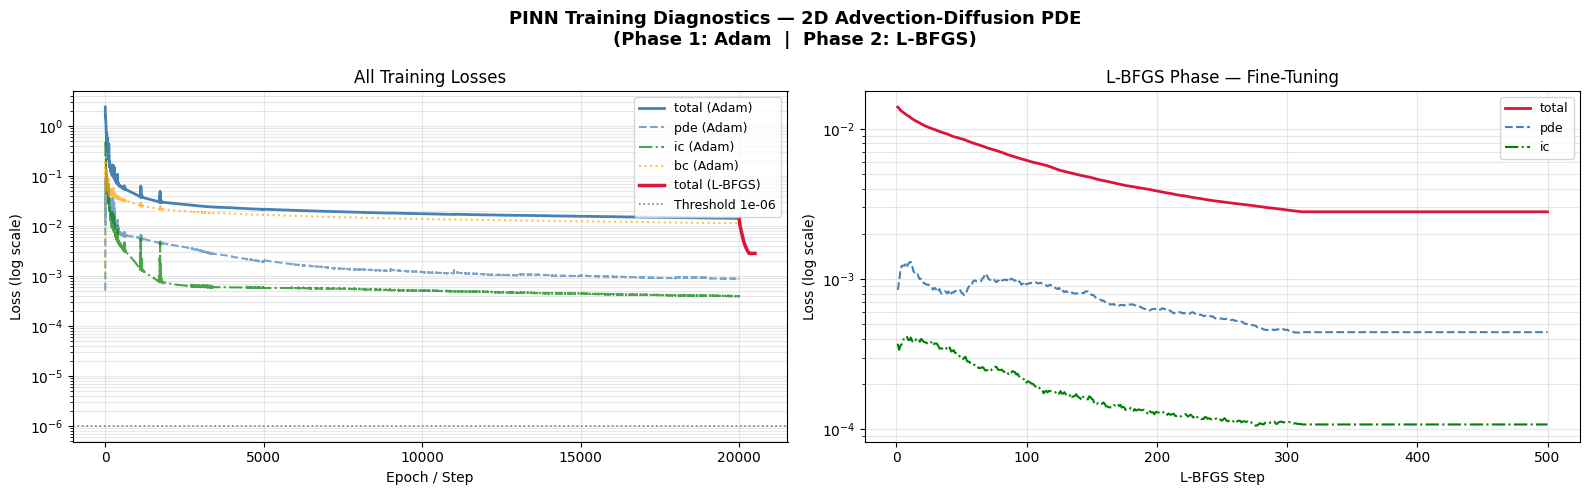

  -> saved PINN_01_training_losses.png


In [ ]:
# ── PINN Plot 1: Training Loss Curves (Adam + L-BFGS) ─────────────────────────
ep_a_pinn  = np.arange(1, pinn_final_epoch + 1)
ep_lbfgs   = np.arange(pinn_final_epoch + 1, pinn_final_epoch + 1 + len(lbfgs_loss_hist))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PINN Training Diagnostics — 2D Advection-Diffusion PDE\n'
             '(Phase 1: Adam  |  Phase 2: L-BFGS)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 0], label='total (Adam)',  linewidth=2, color='steelblue')
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 1], label='pde (Adam)',   linewidth=1.5, linestyle='--', color='steelblue', alpha=0.7)
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 2], label='ic (Adam)',    linewidth=1.5, linestyle='-.', color='green', alpha=0.7)
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 3], label='bc (Adam)',    linewidth=1.5, linestyle=':', color='orange', alpha=0.7)
if len(lbfgs_loss_hist):
    ax.semilogy(ep_lbfgs, lbfgs_loss_hist[:, 0], label='total (L-BFGS)', linewidth=2.5, color='crimson')
ax.axhline(PINN_EARLY_THRESH, color='gray', ls=':', lw=1.2, label=f'Threshold {PINN_EARLY_THRESH:.0e}')
ax.set_xlabel('Epoch / Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('All Training Losses'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
if len(lbfgs_loss_hist):
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 0],
                lw=2, color='crimson', label='total')
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 1],
                lw=1.5, color='steelblue', ls='--', label='pde')
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 2],
                lw=1.5, color='green', ls='-.', label='ic')
ax.set_xlabel('L-BFGS Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('L-BFGS Phase — Fine-Tuning'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
save_and_show('PINN_01_training_losses.png')


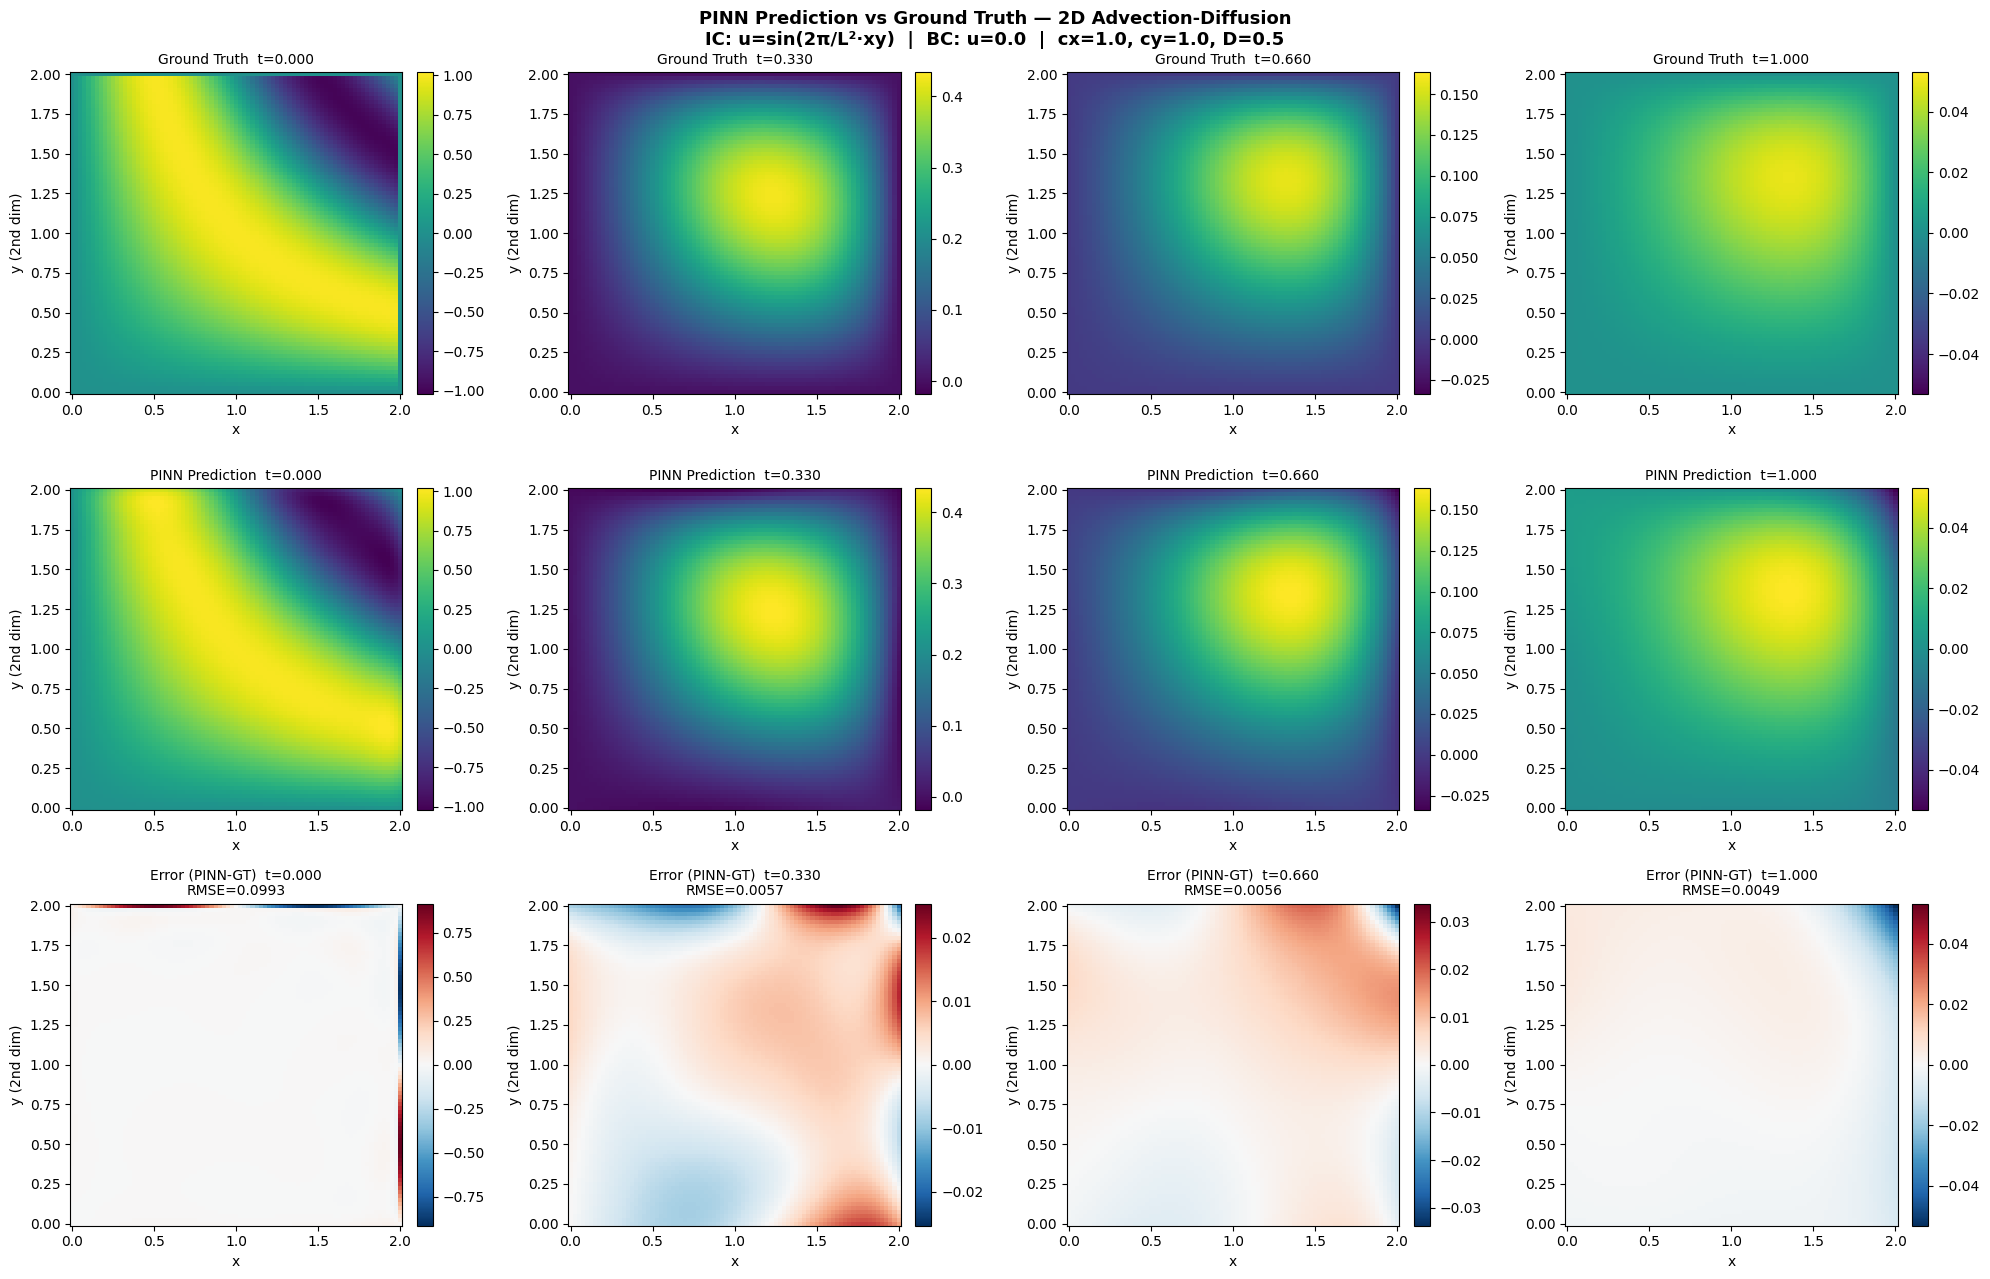

  -> saved PINN_02_snapshot_comparison.png


In [ ]:
# ── PINN Plot 2: Ground Truth vs PINN vs Error (4 snapshots) ──────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'PINN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Upinn = PINN_pred_snaps[si]
    err   = Upinn - Ugt
    vmin  = min(Ugt.min(), Upinn.min()); vmax = max(Ugt.max(), Upinn.max())
    emax  = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Upinn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'PINN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_p = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (PINN-GT)  t={tk:.3f}\nRMSE={rmse_p:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('PINN_02_snapshot_comparison.png')

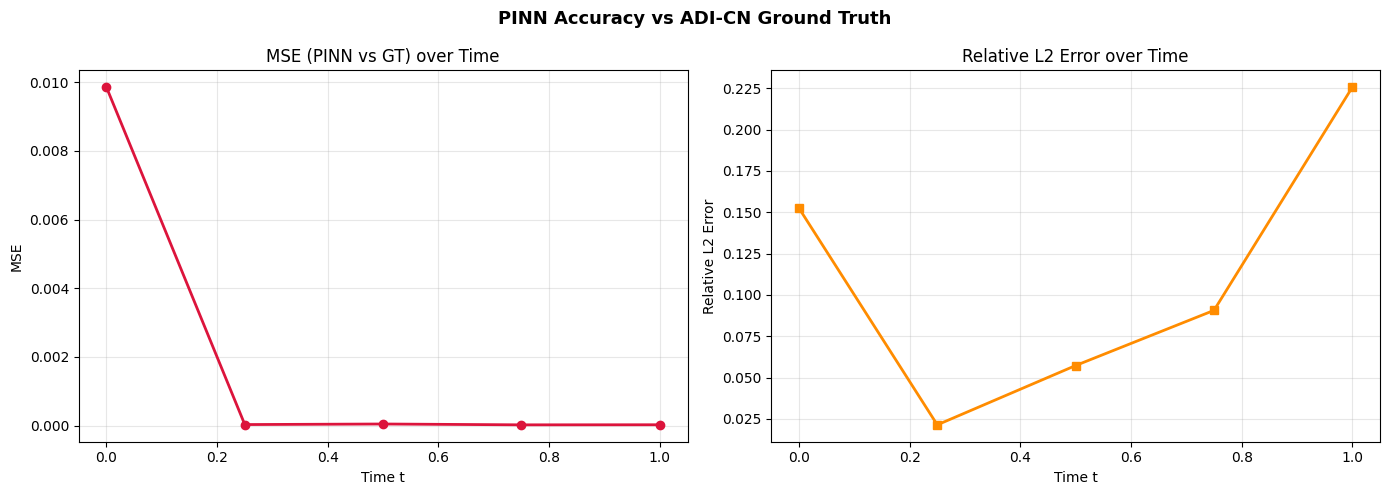

  -> saved PINN_03_accuracy_over_time.png


In [ ]:
# ── PINN Plot 3: Accuracy Over Time ───────────────────────────────────────────
pinn_rmse_t    = [np.sqrt(np.mean((PINN_pred_snaps[k] - KAN_true_snaps[k])**2)) for k in range(len(snap_t))]
pinn_time_eval = [m[0] for m in pinn_metrics]
pinn_mse_eval  = [m[2] for m in pinn_metrics]
pinn_rl2_eval  = [m[1] for m in pinn_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PINN Accuracy vs ADI-CN Ground Truth', fontsize=13, fontweight='bold')

axes[0].plot(pinn_time_eval, pinn_mse_eval, marker='o', linewidth=2, color='crimson')
axes[0].set_xlabel('Time t'); axes[0].set_ylabel('MSE')
axes[0].set_title('MSE (PINN vs GT) over Time'); axes[0].grid(True, alpha=0.3)

axes[1].plot(pinn_time_eval, pinn_rl2_eval, marker='s', linewidth=2, color='darkorange')
axes[1].set_xlabel('Time t'); axes[1].set_ylabel('Relative L2 Error')
axes[1].set_title('Relative L2 Error over Time'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('PINN_03_accuracy_over_time.png')

## 11. KAN vs PINN — Comparative Analysis

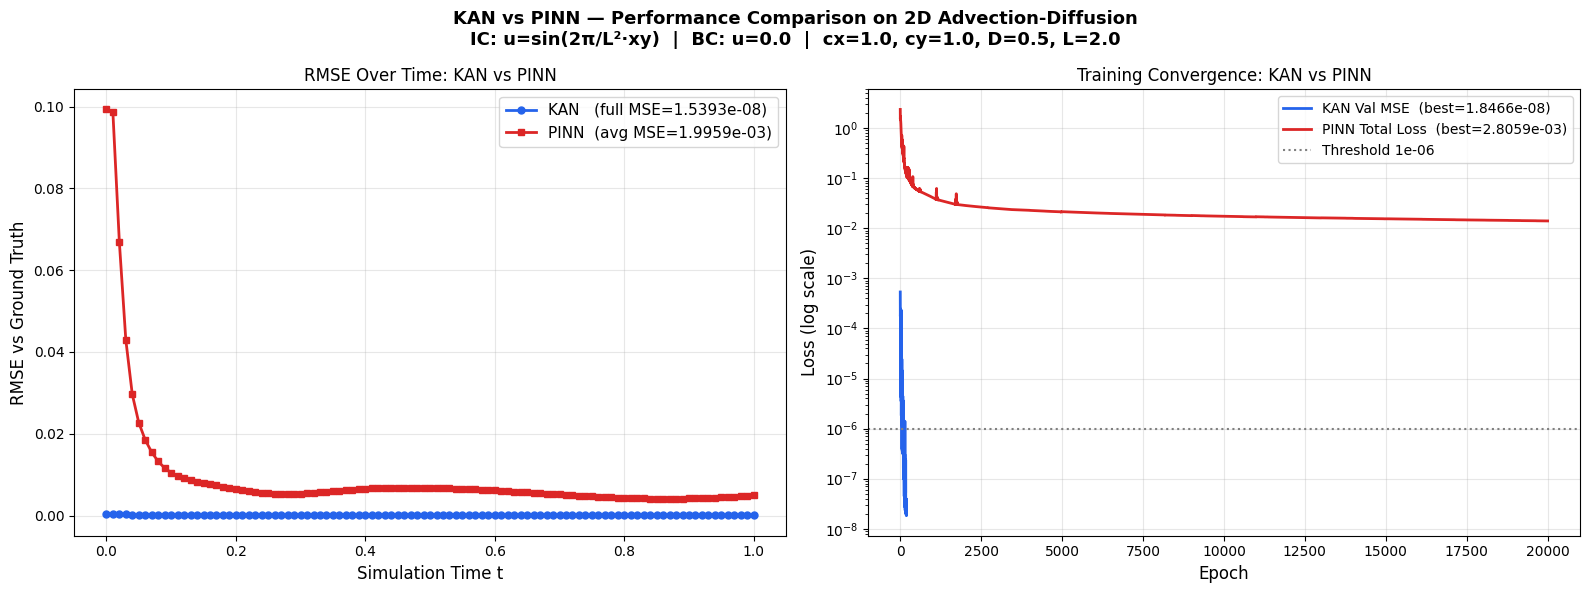

  -> saved COMPARE_01_rmse_and_convergence.png


In [ ]:
# ── Comparison Plot 1: RMSE over Time & Training Convergence ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'KAN vs PINN — Performance Comparison on 2D Advection-Diffusion\n'
    f'IC: u=sin(2π/L²·xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}, L={L}',
    fontsize=13, fontweight='bold'
)

ax = axes[0]
ax.plot(snap_t, kan_rmse_t,  'o-', color='#2563EB', lw=2, ms=5, label=f'KAN   (full MSE={kan_mse_full:.4e})')
ax.plot(snap_t, pinn_rmse_t, 's-', color='#DC2626', lw=2, ms=5, label=f'PINN  (avg MSE={np.mean(pinn_mse_eval):.4e})')
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE vs Ground Truth', fontsize=FS)
ax.set_title('RMSE Over Time: KAN vs PINN', fontsize=FS)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(np.arange(1, kan_final_epoch + 1), kan_val_losses,
            lw=2, color='#2563EB', label=f'KAN Val MSE  (best={kan_best_val:.4e})')
ax.semilogy(np.arange(1, pinn_final_epoch + 1), pinn_loss_hist[:, 0],
            lw=2, color='#DC2626', label=f'PINN Total Loss  (best={pinn_best_loss:.4e})')
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.5, label=f'Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Loss (log scale)', fontsize=FS)
ax.set_title('Training Convergence: KAN vs PINN', fontsize=FS)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_01_rmse_and_convergence.png')

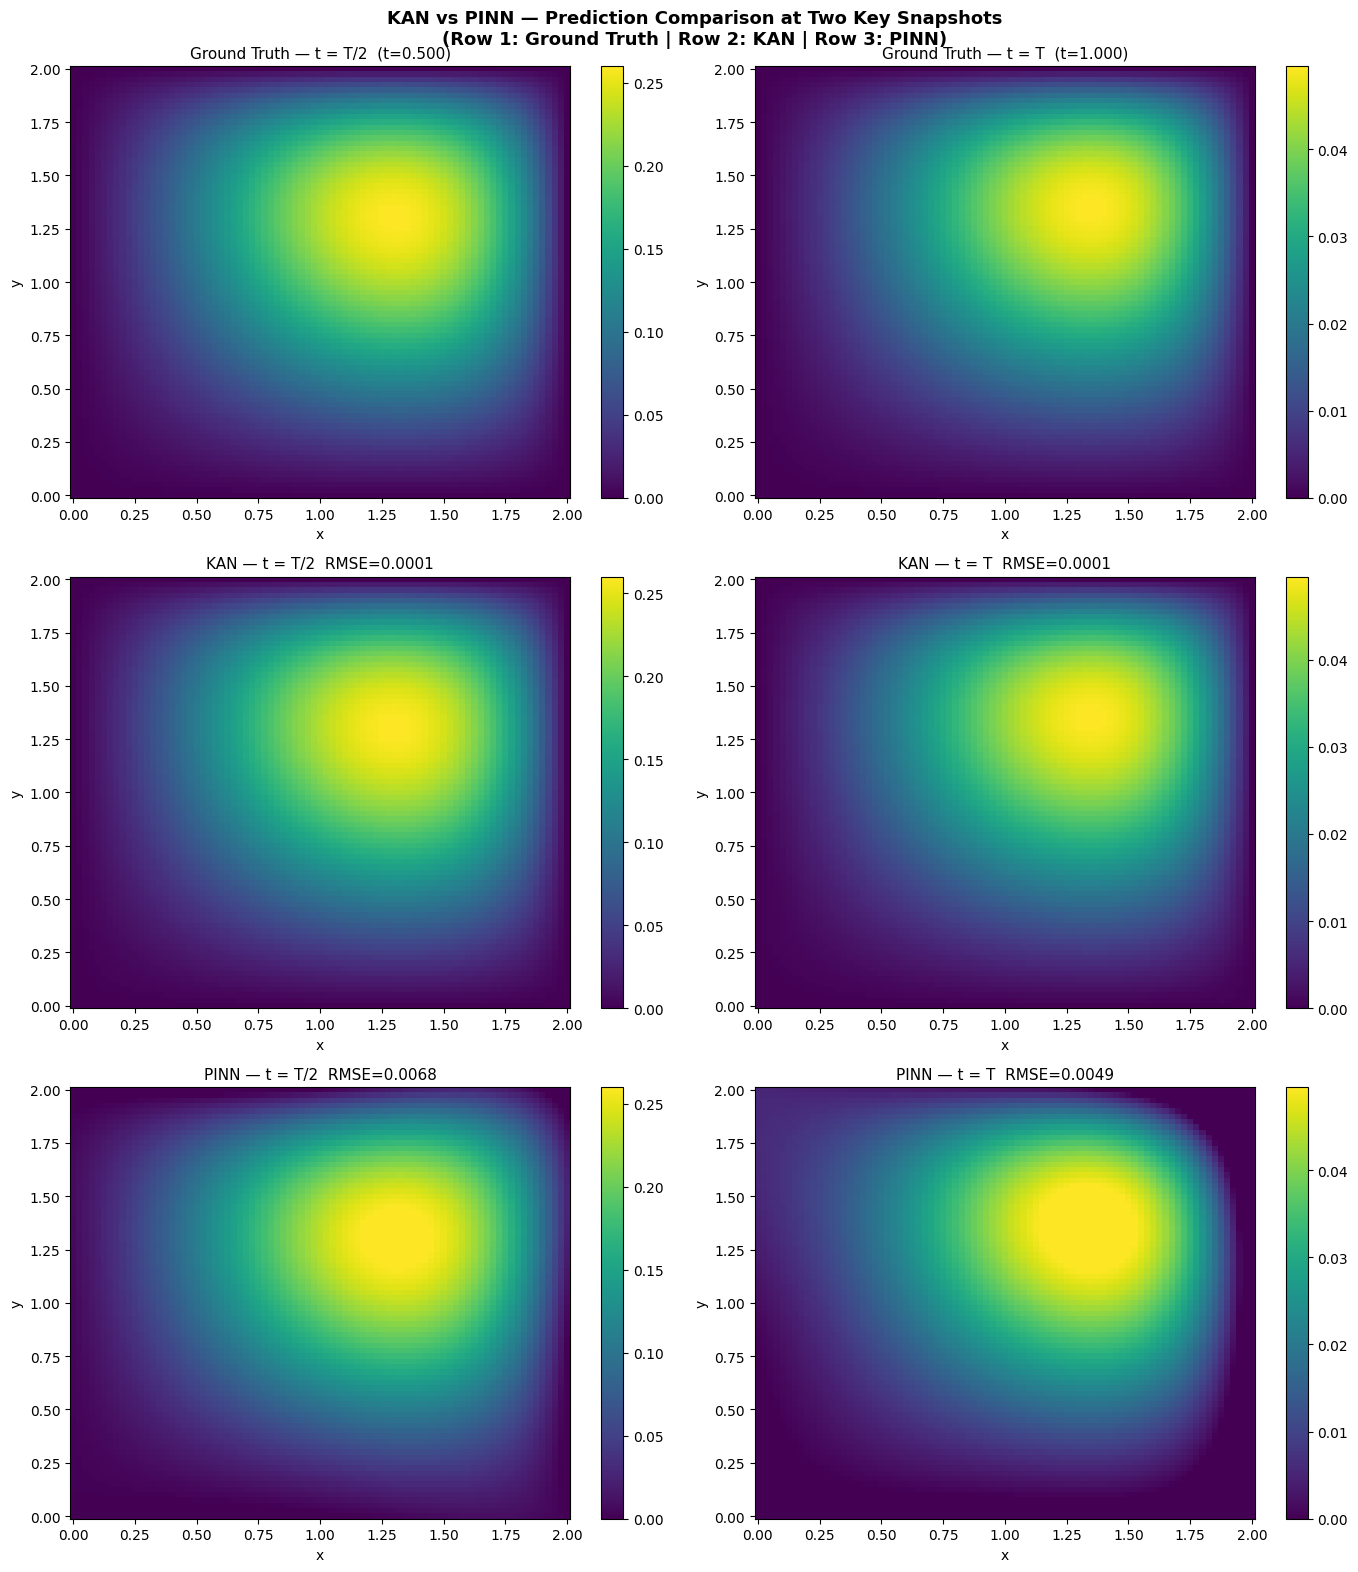

  -> saved COMPARE_02_side_by_side_predictions.png


In [ ]:
# ── Comparison Plot 2: Side-by-side predictions at t=T/2 and t=T ──────────────
compare_snaps  = [len(snap_t) // 2, len(snap_t) - 1]
compare_labels = ['t = T/2', 't = T']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle(
    'KAN vs PINN — Prediction Comparison at Two Key Snapshots\n'
    '(Row 1: Ground Truth | Row 2: KAN | Row 3: PINN)',
    fontsize=13, fontweight='bold'
)

for col, (si, label) in enumerate(zip(compare_snaps, compare_labels)):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Ukn   = KAN_pred_snaps[si]
    Upinn = PINN_pred_snaps[si]
    vmin  = Ugt.min(); vmax = Ugt.max()

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth — {label}  (t={tk:.3f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_k = np.sqrt(np.mean((Ukn - Ugt)**2))
    ax.set_title(f'KAN — {label}  RMSE={rmse_k:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, Upinn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_p = np.sqrt(np.mean((Upinn - Ugt)**2))
    ax.set_title(f'PINN — {label}  RMSE={rmse_p:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_02_side_by_side_predictions.png')

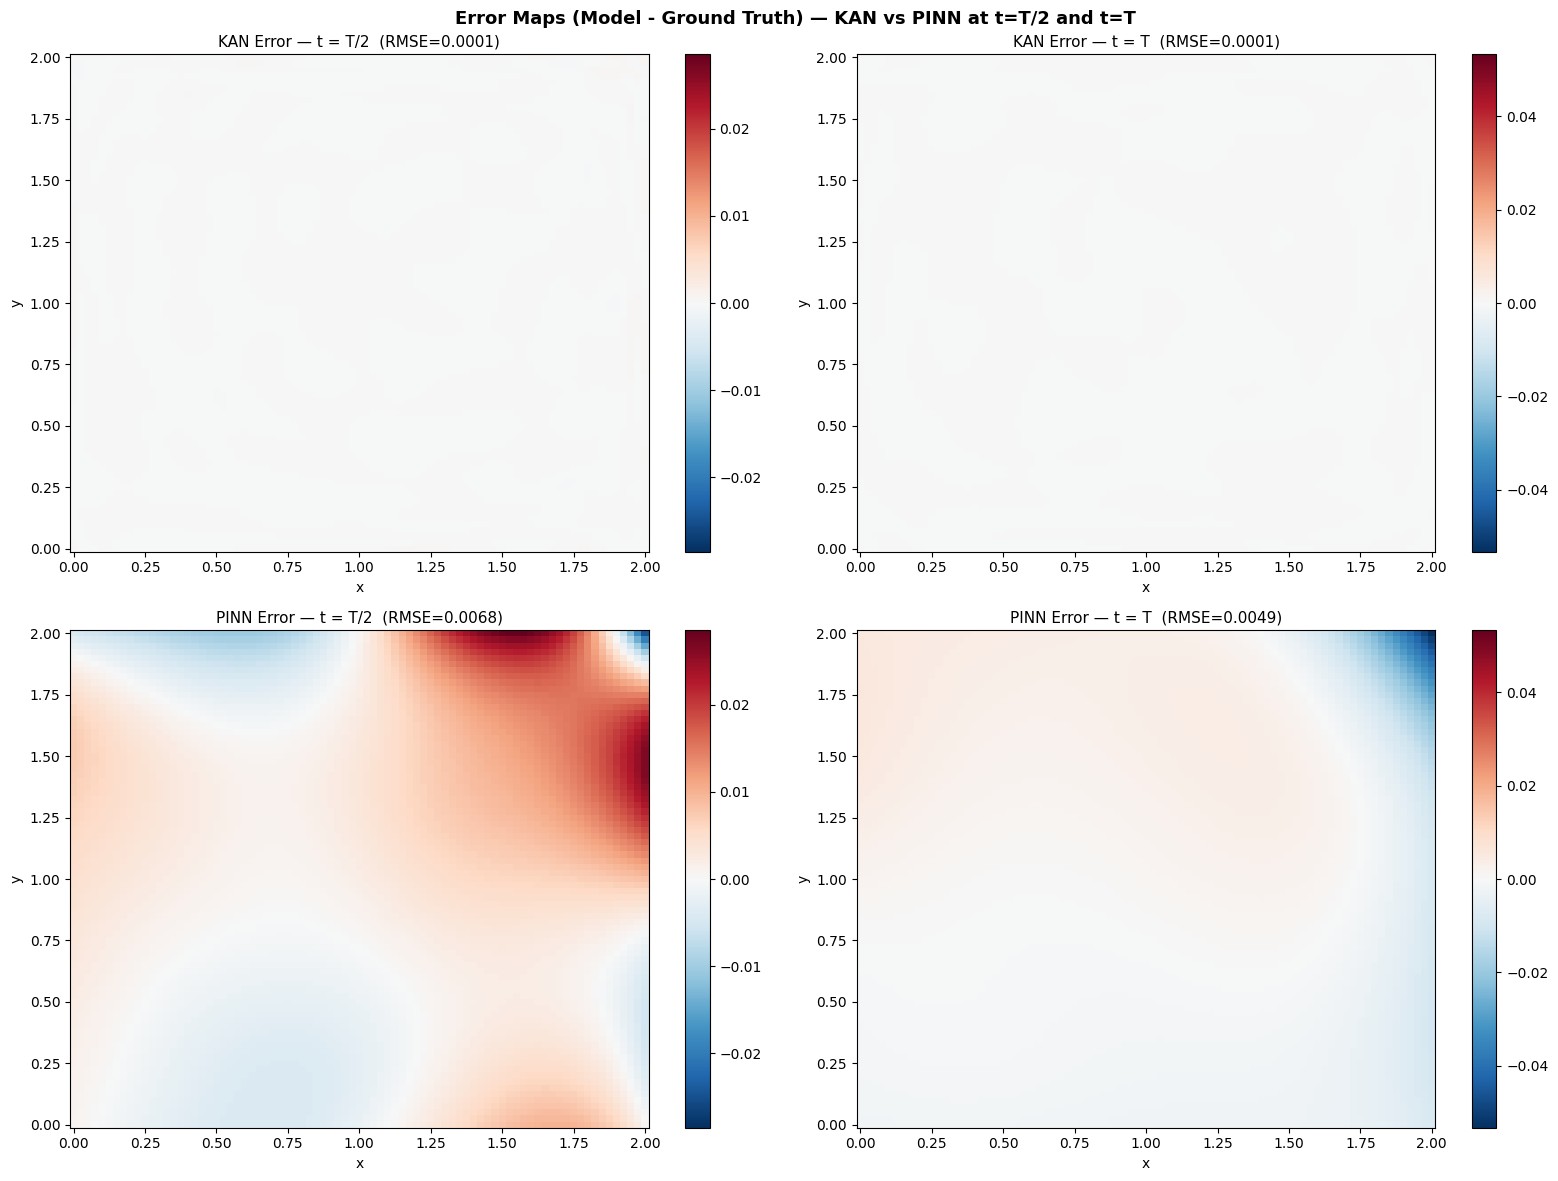

  -> saved COMPARE_03_error_maps.png


In [ ]:
# ── Comparison Plot 3: Error maps KAN vs PINN ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Error Maps (Model - Ground Truth) — KAN vs PINN at t=T/2 and t=T',
             fontsize=13, fontweight='bold')

for col, (si, label) in enumerate(zip(compare_snaps, compare_labels)):
    Ugt   = KAN_true_snaps[si]
    err_k = KAN_pred_snaps[si] - Ugt
    err_p = PINN_pred_snaps[si] - Ugt
    emax  = max(abs(err_k).max(), abs(err_p).max()) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, err_k.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'KAN Error — {label}  (RMSE={np.sqrt(np.mean(err_k**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, err_p.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'PINN Error — {label}  (RMSE={np.sqrt(np.mean(err_p**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_03_error_maps.png')

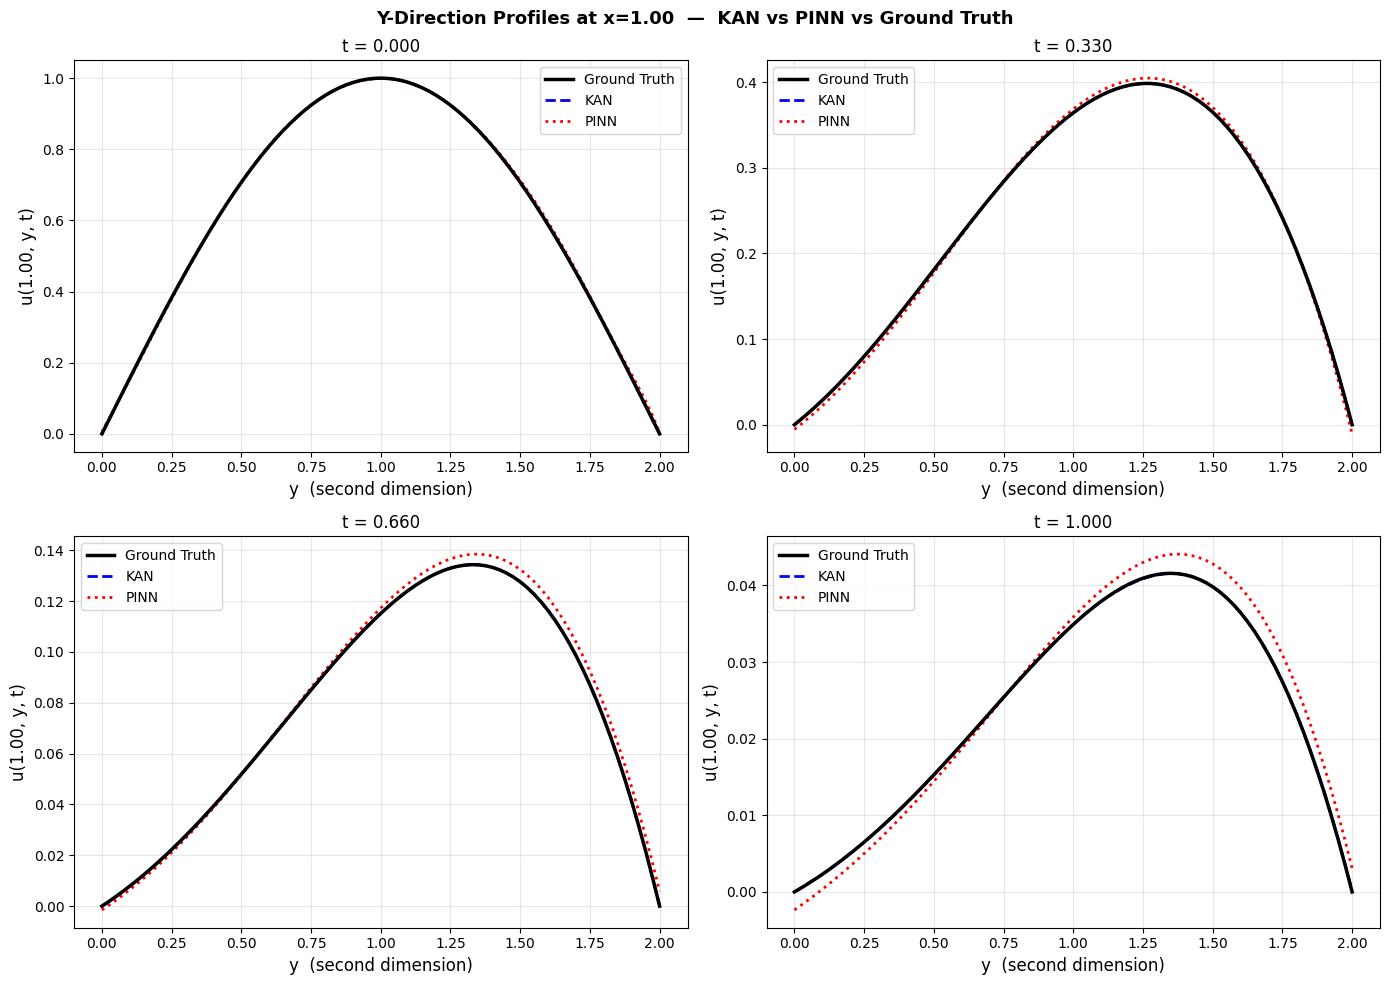

  -> saved COMPARE_04_y_profiles.png


In [ ]:
# ── Comparison Plot 4: Y-Profiles — KAN vs PINN vs GT ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  —  KAN vs PINN vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    kn_y = KAN_pred_snaps[si, ix_mid, :]
    pn_y = PINN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.5, label='Ground Truth', zorder=3)
    ax.plot(y_grid, kn_y, 'b--', lw=2.0, label='KAN')
    ax.plot(y_grid, pn_y, 'r:',  lw=2.0, label='PINN')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_04_y_profiles.png')

## 12. Final Summary

In [ ]:
print('\n' + '=' * 70)
print('  FINAL SUMMARY — KAN & PINN on 2D Advection-Diffusion PDE')
print('=' * 70)
print(f'  PDE       : du/dt + {CX}*du/dx + {CY}*du/dy = {D}*(d2u/dx2 + d2u/dy2)')
print(f'  IC        : u(x,y,0) = sin(2*pi/L^2 * x*y)')
print(f'  BC        : u = {BC_VAL} on all boundaries (Dirichlet)')
print(f'  Domain    : x,y in [0,{L}],  t in [0,{T}]')
print(f'  Grid      : Nx=Ny={Nx}, Dx=Dy={DX:.4f}, Dt={DT}')
print(f'  GT Solver : ADI-Crank-Nicolson (IMEX, upwind advection)')
print(f'  Inputs    : normalised to [-1, 1] for BOTH models')
print()
print(f'  ── KAN ──────────────────────────────────────────────────────')
print(f'  Architecture  : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}')
print(f'  Parameters    : {kan_n_params:,}')
print(f'  Training      : Supervised regression on {len(snap_t)} GT snapshots')
print(f'  Optimiser     : AdamW  lr=3e-3  ReduceLROnPlateau')
print(f'  Threshold     : {KAN_THRESHOLD:.0e}  Patience={KAN_PATIENCE}')
print(f'  Stop reason   : {kan_stop_reason}')
print(f'  Epochs run    : {kan_final_epoch}')
print(f'  Best val MSE  : {kan_best_val:.6f}')
print(f'  Full MSE      : {kan_mse_full:.6f}')
print(f'  RMSE          : {kan_rmse_all:.6f}')
print(f'  Rel. L1 err   : {kan_rel_err*100:.2f} %')
print(f'  Training time : {kan_total_time:.1f}s ({kan_total_time/60:.1f} min)')
print()
print(f'  ── PINN ─────────────────────────────────────────────────────')
print(f'  Architecture  : MLP  width=128  depth=6')
print(f'  Parameters    : {pinn_n_params:,}')
print(f'  Training      : Physics-informed (PDE residual + IC + BC losses)')
print(f'  Loss weights  : w_f={PINN_W_F}, w_ic={PINN_W_IC}, w_bc={PINN_W_BC}')
print(f'  Optimiser     : Adam ({pinn_adam_epochs} epochs) + L-BFGS ({len(lbfgs_loss_hist)} steps)')
print(f'  Threshold     : {PINN_EARLY_THRESH:.0e}  Patience={PINN_EARLY_PATIENCE}')
print(f'  Stop reason   : {pinn_stop_reason}')
print(f'  Adam epochs   : {pinn_adam_epochs}')
print(f'  L-BFGS steps  : {len(lbfgs_loss_hist)}')
print(f'  Best loss     : {pinn_best_loss:.6f}')
print(f'  Avg MSE (eval): {np.mean(pinn_mse_eval):.6f}')
print(f'  Training time : {pinn_total_time:.1f}s ({pinn_total_time/60:.1f} min)')
print()
print(f'  All plots saved to: {OUT_DIR}/')
print('=' * 70)



  FINAL SUMMARY — KAN & PINN on 2D Advection-Diffusion PDE
  PDE       : du/dt + 1.0*du/dx + 1.0*du/dy = 0.5*(d2u/dx2 + d2u/dy2)
  IC        : u(x,y,0) = sin(2*pi/L^2 * x*y)
  BC        : u = 0.0 on all boundaries (Dirichlet)
  Domain    : x,y in [0,2.0],  t in [0,1.0]
  Grid      : Nx=Ny=80, Dx=Dy=0.0250, Dt=0.002
  GT Solver : ADI-Crank-Nicolson (IMEX, upwind advection)
  Inputs    : normalised to [-1, 1] for BOTH models

  ── KAN ──────────────────────────────────────────────────────
  Architecture  : [3, 32, 32, 32, 1]  grid=8  order=3
  Parameters    : 26,304
  Training      : Supervised regression on 101 GT snapshots
  Optimiser     : AdamW  lr=3e-3  ReduceLROnPlateau
  Threshold     : 1e-06  Patience=50
  Stop reason   : convergence
  Epochs run    : 195
  Best val MSE  : 0.000000
  Full MSE      : 0.000000
  RMSE          : 0.000124
  Rel. L1 err   : 0.06 %
  Training time : 2863.3s (47.7 min)

  ── PINN ─────────────────────────────────────────────────────
  Architecture  : M